# Experiment with the plotting class object and its methods

Load the auxillary datasets for Amundsen Sea Embayment

In [1]:
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
from src.plotting import Plotting
from src.utilities import load_ase_datasets

aux_data = load_ase_datasets()
xs_ase, ys_ase = aux_data['coords']['xs'], aux_data['coords']['ys']
print("Keys of the auxiliary data dictionary:", aux_data.keys())


  [load_ase_datasets] Loading reference coordinates …
  [load_ase_datasets] Loading Bedmap3 …
  [load_ase_datasets] Computing Tpmp …
  [load_ase_datasets] Computing surface slope …
  [load_ase_datasets] Loading velocity …
  [load_ase_datasets] Loading domain mask …
  [load_ase_datasets] All datasets ready.
Keys of the auxiliary data dictionary: dict_keys(['coords', 'sdem', 'bed', 'H', 'Tpmp', 'slope_x', 'slope_y', 'slope_mag', 'vx', 'vy', 'vel', 'mask'])


# Posterior

Plot the posterior mean and STD

In [2]:
import scipy.io
import numpy as np
import os
import torch
from src.ice import compute_pmp, enthalpy_to_temperature

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
H_filename      = 'H_gridded.mat'
folder = data_path
nx, ny = 256, 256

beta = 1
posterior_path = f"../data/posterior-hmc-samples/Eb_samples_ori_beta_{beta}.npy"
posterior_samples = np.load(posterior_path)
num_samples = posterior_samples.shape[0]
print("Shape of the posterior samples:", posterior_samples.shape)

# compute pmp
H_data = scipy.io.loadmat(folder + H_filename)

H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# ── Convert to temperature ─────────────────────────────────────────────
Tb_samples = np.zeros_like(posterior_samples)

for i in range(num_samples):
    Eb_i   = torch.from_numpy(posterior_samples[i])
    Tpmp_i = torch.from_numpy(pmp) if isinstance(pmp, np.ndarray) else pmp
    Tb_samples[i] = enthalpy_to_temperature(Eb_i, Tpmp_i).numpy()

# ── Statistics ────────────────────────────────────────────────────────
Tb_std  = np.std(Tb_samples,  axis=0).reshape(nx, ny)
Tb_mean = np.mean(Tb_samples, axis=0).reshape(nx, ny)

dTpmp_mean = pmp.reshape(nx, ny) - Tb_mean


Shape of the posterior samples: (3000, 65536)


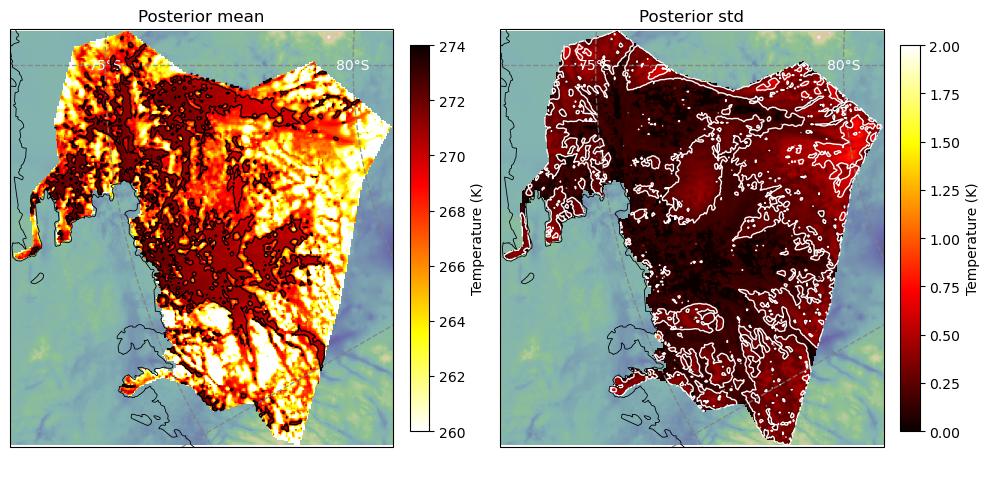

In [10]:
plotit = Plotting()

Tb_mean[aux_data['mask']==0] = np.nan
Tb_std[aux_data['mask']==0] = np.nan

data1 = dict(
    x = xs_ase,
    y = ys_ase,
    data = Tb_mean,
    vmin = 260,
    vmax = 274,
    contour_data = dTpmp_mean, 
    contour_levels = [1],
    contour_colors = ['black'],
    cmap = 'hot_r',
    title = 'Posterior mean',
    cb_label = 'Temperature (K)'
)
data2 = dict(
    x = xs_ase,
    y = ys_ase,
    data = Tb_std,
    vmin = 0,
    vmax = 2,
    cmap = 'hot',
    contour_data = Tb_std, 
    contour_levels = [0.2, 0.5],
    title = 'Posterior std',
    cb_label = 'Temperature (K)'
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = aux_data['bed'],
    cmap = 'gist_earth',
)

plotit.define_extent(xs_ase, ys_ase)
plotit.plot((data1, data2), background)

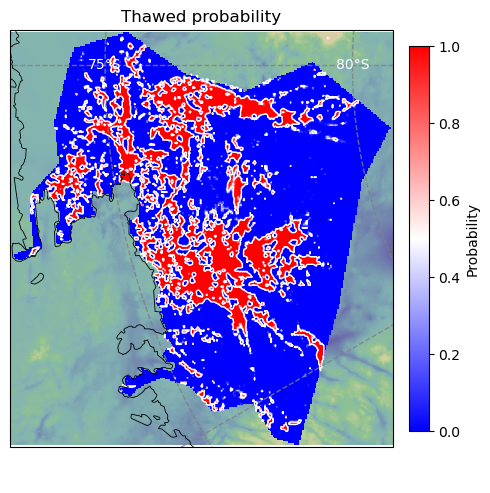

In [12]:
# compute thawed probability. This is defined by the fraction of samples that are within epsilon degree of PMP
def compute_thawed_probability(Tb_samples, pmp, epsilon=1):
    """
    Parameters
    ----------
    Tb_samples : (n_samples, n_pixels)  – posterior samples, spatially flattened
    pmp        : (nx, ny) or (n_pixels,) – pressure melting point
    epsilon    : float – tolerance in K

    Returns
    -------
    thawed_probability : (n_pixels,) – fraction of samples within epsilon of PMP
    """
    pmp_flat   = pmp.ravel()                          # (n_pixels,)
    # Tb_samples : (n_samples, n_pixels)  ✅ shapes now align on axis=1
    diff       = np.abs(pmp_flat[np.newaxis, :] - Tb_samples)   # (n_samples, n_pixels)
    thawed_count = np.sum(diff <= epsilon, axis=0)               # (n_pixels,)
    return thawed_count / Tb_samples.shape[0]


thawed_probability = compute_thawed_probability(Tb_samples, pmp, epsilon=1).reshape(nx, ny)
thawed_probability[aux_data['mask']==0] = np.nan
thawed_prob_data = dict(
    x = xs_ase,
    y = ys_ase,
    data = thawed_probability,
    vmin = 0,
    vmax = 1,
    cmap = 'bwr',
    contour_data = dTpmp_mean, 
    contour_levels = [1],
    title = 'Thawed probability',
    cb_label = 'Probability'
)
plotit.plot((thawed_prob_data,), background)